In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
valuation = pd.read_csv("../reports/valuation_flags.csv")

valuation.head()

,company_id,roe,opm_percentage,net_profit,eps,profit_before_tax,valuation_score,valuation_rating
0,ABB,0.0,12.0,145,68.0,215,47.1,Weak
1,ABB,0.0,12.0,198,93.0,295,63.0,Moderate
2,ABB,0.0,14.0,229,108.0,344,72.9,Moderate
3,ABB,0.0,14.0,255,120.0,398,80.7,Moderate
4,ABB,0.0,14.0,277,130.0,436,87.3,Moderate


In [3]:
features = valuation[
    [
        "roe",
        "opm_percentage",
        "net_profit",
        "valuation_score"
    ]
]

features.head()

,roe,opm_percentage,net_profit,valuation_score
0,0.0,12.0,145,47.1
1,0.0,12.0,198,63.0
2,0.0,14.0,229,72.9
3,0.0,14.0,255,80.7
4,0.0,14.0,277,87.3


In [4]:
features = features.fillna(0)

features.isnull().sum()

roe                0
opm_percentage     0
net_profit         0
valuation_score    0
dtype: int64

In [5]:
scaler = StandardScaler()

scaled = scaler.fit_transform(features)

scaled[:5]

array([[-0.30042397, -0.05736437, -0.61914149, -0.59086461],
       [-0.30042397, -0.05736437, -0.61456846, -0.58672412],
       [-0.30042397, -0.05706644, -0.61189366, -0.58414607],
       [-0.30042397, -0.05706644, -0.60965029, -0.58211489],
       [-0.30042397, -0.05706644, -0.60775205, -0.58039619]])

In [6]:
inertia = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled)

    inertia.append(model.inertia_)

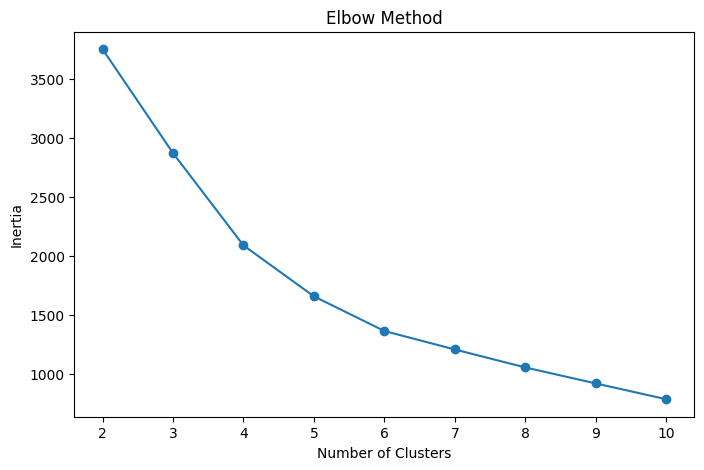

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

os.makedirs("../reports", exist_ok=True)

plt.savefig("../reports/elbow_plot.png")

plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

valuation["cluster_id"] = kmeans.fit_predict(scaled)

valuation.head()

,company_id,roe,opm_percentage,net_profit,eps,profit_before_tax,valuation_score,valuation_rating,cluster_id
0,ABB,0.0,12.0,145,68.0,215,47.1,Weak,1
1,ABB,0.0,12.0,198,93.0,295,63.0,Moderate,1
2,ABB,0.0,14.0,229,108.0,344,72.9,Moderate,1
3,ABB,0.0,14.0,255,120.0,398,80.7,Moderate,1
4,ABB,0.0,14.0,277,130.0,436,87.3,Moderate,1


In [9]:
cluster_names = {

    0: "High Growth",

    1: "Stable",

    2: "Value",

    3: "Moderate",

    4: "Emerging"

}

valuation["cluster_name"] = valuation["cluster_id"].map(cluster_names)

In [10]:
os.makedirs("../output", exist_ok=True)

valuation[
    [
        "company_id",
        "cluster_id",
        "cluster_name"
    ]
].to_csv(
    "../output/cluster_labels.csv",
    index=False
)

print("Cluster labels generated successfully.")

Cluster labels generated successfully.
